<a href="https://colab.research.google.com/github/RamcharanChandragiri/NATURAL-LANGUAGE-PROCESSING/blob/main/Lab_09_wordembeddings_RAMCHARAN_2403A52069.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1.Import required libraries

Import libraries for:

• loading embeddings

• similarity calculations

• visualization

In [ ]:
# =========================
# Loading / Creating Embeddings
# =========================
import numpy as np
from sentence_transformers import SentenceTransformer
from transformers import AutoTokenizer, AutoModel
import torch

# =========================
# Similarity Calculations
# =========================
from sklearn.metrics.pairwise import cosine_similarity
from scipy.spatial.distance import cdist

# =========================
# Visualization
# =========================
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Optional: Improve plot styling
sns.set(style="whitegrid")


2.Load Pre-trained Embeddings

Students should:

• load Word2Vec or GloVe

• print vocabulary size

• display example word vectors

In [ ]:
!pip install gensim
import gensim.downloader as api

# Load pre-trained Word2Vec model (Google News, 300-dim)
model = api.load("word2vec-google-news-300")

# Print vocabulary size
print("Vocabulary size:", len(model.key_to_index))

# Display vector for an example word
word = "computer"
print(f"\nVector for '{word}':\n", model[word])
print("Vector dimension:", len(model[word]))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 61.6 MB/s eta 0:00:00
[==================================================] 100.0% 1662.8/1662.8MB downloaded
Vocabulary size: 3000000

Vector for 'computer':
 [ 1.07421875e-01 -2.01171875e-01  1.23046875e-01  2.11914062e-01
 -9.13085938e-02  2.16796875e-01 -1.31835938e-01  8.30078125e-02
  2.02148438e-01  4.78515625e-02  3.66210938e-02 -2.45361328e-02
  2.39257812e-02 -1.60156250e-01 -2.61230469e-02  9.71679688e-02
 -6.34765625e-02  1.84570312e-01  1.70898438e-01 -1.63085938e-01
 -1.09375000e-01  1.49414062e-01 -4.65393066e-04  9.61914062e-02
  1.68945312e-01  2.60925293e-03  8.93554688e-02  6.49414062e-02
  3.56445312e-02 -6.93359375e-02 -1.46484375e-01 -1.21093750e-01
 -2.27539062e-01  2.45361328e-02 -1.24511719e-01 -3.18359375e-01
 -2.20703125e-01  1.30859375e-01  3.66210938e-02 -3.63769531e-02
 -1.13281250e-01  1.95312500e-01  9.76562500e-02  1.26953125e-01
  6.59179688e-02  6.93359375e-02  1.02539062e-02  1.75781250e-01
 -1.

Explore Word Similarity

Students should:

• compute similarity for at least 10 word pairs

(example: doctor–nurse, cat–dog, car–bus)

In [2]:
import gensim.downloader as api

# Load GloVe model
model = api.load("glove-wiki-gigaword-100")

print("Vocabulary size:", len(model.key_to_index))
word = "computer"
vector = model[word]

print("\nExample word:", word)
print("Vector (first 10 values):", vector[:10])
print("Vector dimension:", len(vector))


Vocabulary size: 400000

Example word: computer
Vector (first 10 values): [-0.16298   0.30141   0.57978   0.066548  0.45835  -0.15329   0.43258
 -0.89215   0.57747   0.36375 ]
Vector dimension: 100


In [3]:
word_pairs = [
    ("doctor", "nurse"),
    ("cat", "dog"),
    ("car", "bus"),
    ("king", "queen"),
    ("apple", "banana"),
    ("man", "woman"),
    ("teacher", "student"),
    ("paris", "france"),
    ("coffee", "tea"),
    ("computer", "internet")
]

print("Word Similarities:\n")

for w1, w2 in word_pairs:
    similarity = model.similarity(w1, w2)
    print(f"{w1:10s} - {w2:10s} : {similarity:.4f}")


Word Similarities:

doctor     - nurse      : 0.7522
cat        - dog        : 0.8798
car        - bus        : 0.7373
king       - queen      : 0.7508
apple      - banana     : 0.5054
man        - woman      : 0.8323
teacher    - student    : 0.8083
paris      - france     : 0.7482
coffee     - tea        : 0.7733
computer   - internet   : 0.7287


Nearest neighbour Exploration

For at least 5 chosen words, display top similar words.

Example questions to analyze:

• What words appear near “king”?

• What words appear near “university”?

• Are there thematic clusters?

In [4]:
test_words = ["king", "university", "hospital", "music", "technology"]

for word in test_words:
    print(f"\nTop similar words for '{word}':")
    for similar_word, score in model.most_similar(word, topn=5):
        print(f"{similar_word:15s} {score:.4f}")



Top similar words for 'king':
prince          0.7682
queen           0.7508
son             0.7021
brother         0.6986
monarch         0.6978

Top similar words for 'university':
college         0.8294
harvard         0.8156
yale            0.8114
professor       0.8104
graduate        0.7993

Top similar words for 'hospital':
clinic          0.8140
medical         0.7816
hospitals       0.7696
nursing         0.7148
hospitalized    0.6945

Top similar words for 'music':
musical         0.8128
songs           0.7978
dance           0.7897
pop             0.7863
recording       0.7651

Top similar words for 'technology':
technologies    0.8506
computer        0.7642
tech            0.7489
software        0.7359
systems         0.7293


Word Analogy Tasks

Students must perform analogy queries:

Examples:

• king − man + woman = ?

• paris − france + india = ?

• teacher − school + hospital = ?

In [5]:
print("king - man + woman =",
      model.most_similar(positive=["king", "woman"], negative=["man"], topn=1))

print("paris - france + india =",
      model.most_similar(positive=["paris", "india"], negative=["france"], topn=1))

print("teacher - school + hospital =",
      model.most_similar(positive=["teacher", "hospital"], negative=["school"], topn=1))


king - man + woman = [('queen', 0.7698540687561035)]
paris - france + india = [('delhi', 0.8654932975769043)]
teacher - school + hospital = [('nurse', 0.7798740267753601)]


Visualization

Students may:

• pick 20–30 words

• reduce dimensions (PCA/TSNE)

• plot scatter chart

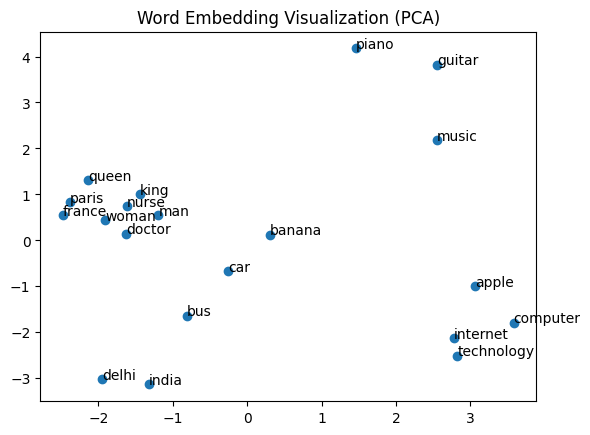

In [7]:
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Select words
words = ["king", "queen", "man", "woman", "doctor", "nurse",
         "apple", "banana", "car", "bus",
         "paris", "france", "india", "delhi",
         "music", "guitar", "piano",
         "computer", "internet", "technology"]

# Get vectors
word_vectors = np.array([model[word] for word in words])

# Reduce dimensions
pca = PCA(n_components=2)
reduced = pca.fit_transform(word_vectors)

# Plot
plt.figure()
plt.scatter(reduced[:, 0], reduced[:, 1])

for i, word in enumerate(words):
    plt.annotate(word, (reduced[i, 0], reduced[i, 1]))

plt.title("Word Embedding Visualization (PCA)")
plt.show()